# Glassdoor Review Sentiment Analysis — NLP Pipeline

**Dataset:** Glassdoor Employee Reviews (`glassdoor_reviews.csv`) — 838,566 raw reviews  
**Task:** Binary Sentiment Classification — Positive (rating ≥ 4) vs Negative (rating ≤ 2)  
**Scope:** Tech · Consulting · Finance firms only  
**Model:** TF-IDF + Logistic Regression (sklearn Pipeline)

---

**Pipeline steps:**
1. Import Libraries
2. Load & Inspect Data
3. Drop Missing Values
4. Label Engineering
5. Sector Filtering & Stratified Sampling
6. Text Cleaning
7. Train-Test Split
8. TF-IDF Vectoriser
9. Build sklearn Pipeline
10. Cross-Validation
11. Fit Final Model
12. Evaluation
13. ROC-AUC Curve
14. Top TF-IDF Features
15. Per-Firm Sentiment Analysis
16. Save Artifacts

In [6]:
import os


In [7]:
import re
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
from tqdm import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    f1_score,
    accuracy_score,
    precision_score,
    recall_score,
)
from sklearn.pipeline import Pipeline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

### 2. Load & Inspect Data

In [8]:
gd = pd.read_csv(os.path.join(os.getcwd(), "glassdoor_reviews.csv"))
print(f"Raw shape: {gd.shape}")
print(f"Columns: {gd.columns.tolist()}")
print(f"\nRating distribution:\n{gd['overall_rating'].value_counts().sort_index()}")
print(f"\nSample firms:\n{gd['firm'].value_counts().head(10)}")

Raw shape: (838566, 18)
Columns: ['firm', 'date_review', 'job_title', 'current', 'location', 'overall_rating', 'work_life_balance', 'culture_values', 'diversity_inclusion', 'career_opp', 'comp_benefits', 'senior_mgmt', 'recommend', 'ceo_approv', 'outlook', 'headline', 'pros', 'cons']

Rating distribution:
overall_rating
1     58958
2     74809
3    194267
4    278277
5    232255
Name: count, dtype: int64

Sample firms:
firm
IBM           60436
McDonald-s    49450
Deloitte      46995
EY            34050
PwC           33227
Oracle        31941
Microsoft     26675
J-P-Morgan    25814
KPMG          24815
Apple         20797
Name: count, dtype: int64


### 3. Drop Missing Values

In [9]:
before = len(gd)
gd = gd.dropna(subset=['pros', 'cons', 'overall_rating']).reset_index(drop=True)
print(f"Dropped {before - len(gd):,} rows with missing pros/cons/overall_rating")
print(f"Shape after drop: {gd.shape}")

Dropped 15 rows with missing pros/cons/overall_rating
Shape after drop: (838551, 18)


### 4. Label Engineering — Sentiment

3-star reviews are ambiguous (neither clearly positive nor negative) and are removed to give the model a cleaner signal. Reviews rated 4–5 are labelled **Positive (1)**; reviews rated 1–2 are labelled **Negative (0)**.

In [10]:
gd = gd[gd['overall_rating'] != 3].reset_index(drop=True)
gd['sentiment_label'] = (gd['overall_rating'] >= 4).astype(int)
print(f"Shape after removing 3-star reviews: {gd.shape}")
print(f"\nSentiment distribution:\n{gd['sentiment_label'].value_counts()}")
print(f"\nPositive rate: {gd['sentiment_label'].mean()*100:.1f}%")

Shape after removing 3-star reviews: (644285, 19)

Sentiment distribution:
sentiment_label
1    510520
0    133765
Name: count, dtype: int64

Positive rate: 79.2%


### 5. Sector Filtering & Stratified Sampling

The dataset contains reviews from fast-food, retail, and hospitality firms. These sectors are excluded because vocabulary, working conditions, and career expectations differ fundamentally from Tech, Consulting, and Finance — mixing them would introduce domain noise. A stratified sample of 50,000 reviews is drawn proportionally by firm and rating to preserve the natural distribution.

In [11]:

FIRM_SECTOR_MAP = {
    # Tech
    "IBM": "Tech", "Microsoft": "Tech", "Oracle": "Tech", "Apple": "Tech",
    "Google": "Tech", "SAP": "Tech", "Salesforce": "Tech", "LinkedIn": "Tech",
    "Cisco-Systems": "Tech", "Facebook": "Tech", "Vodafone": "Tech",

    # Consulting
    "Deloitte": "Consulting", "EY": "Consulting", "PwC": "Consulting",
    "KPMG": "Consulting", "McKinsey-and-Company": "Consulting",

    # Finance
    "J-P-Morgan": "Finance", "Citi": "Finance", "HSBC-Holdings": "Finance",
    "American-Express": "Finance", "Barclays": "Finance",
    "Goldman-Sachs": "Finance", "Thomson-Reuters": "Finance",
    "Morgan-Stanley": "Finance", "Deutsche-Bank": "Finance",

    # Excluded sectors -- named here for documentation/clarity
    "McDonald-s": "Food Service", "Tesco": "Retail", "Pizza-Hut": "Food Service",
    "Marriott-International": "Hospitality", "J-Sainsbury": "Retail",
}

EXCLUDED_SECTORS = ["Food Service", "Retail", "Hospitality"]
ALLOWED_FIRMS = [f for f, sector in FIRM_SECTOR_MAP.items() if sector not in EXCLUDED_SECTORS]

# Filter BEFORE sampling
before = len(gd)
gd = gd[gd['firm'].isin(ALLOWED_FIRMS)].reset_index(drop=True)
print(f"Kept {len(gd):,} rows (dropped {before - len(gd):,} from excluded sectors)")
print(f"\n Firm counts:\n{gd['firm'].value_counts()}")

N_SAMPLE = 50000

gd_sample = (
    gd.groupby(['firm', 'overall_rating'], group_keys=False)
    .apply(lambda x: x.sample(
        n=max(1, round(N_SAMPLE * len(x) / len(gd))),
        random_state=42
    ))
    .reset_index(drop=True)
)
gd_sample = gd_sample.sample(min(N_SAMPLE, len(gd_sample)), random_state=42).reset_index(drop=True)

print(f"\nSample shape: {gd_sample.shape}")
print(f"\nClass split:\n{gd_sample['sentiment_label'].value_counts()}")
print(f"\nTop firms in sample:\n{gd_sample['firm'].value_counts().head(15)}")

Kept 343,246 rows (dropped 301,039 from excluded sectors)

 Firm counts:
firm
IBM                     43350
Deloitte                36365
EY                      25718
PwC                     25292
Microsoft               21962
Oracle                  21824
J-P-Morgan              19678
KPMG                    18322
Apple                   17488
Google                  14600
Citi                    13299
SAP                     12662
HSBC-Holdings            9975
American-Express         7561
Salesforce               7376
Barclays                 7264
Goldman-Sachs            7034
Thomson-Reuters          6978
Morgan-Stanley           6913
Vodafone                 6435
McKinsey-and-Company     4562
Deutsche-Bank            4501
LinkedIn                 3331
Cisco-Systems             433
Facebook                  323
Name: count, dtype: int64

Sample shape: (50000, 19)

Class split:
sentiment_label
1    41901
0     8099
Name: count, dtype: int64

Top firms in sample:
firm
IBM           

### 6. Text Cleaning

Apostrophes are preserved because contractions carry meaningful sentiment signal — "can't grow", "won't improve", "doesn't care" have very different meaning from "grow", "improve", "care". Pros and cons are concatenated into a single `review_text` field to give the model full context from both halves of the review.

In [12]:
def clean_text(text: str) -> str:
    """
    Lowercase and strip non-alpha characters.
    Apostrophes are kept — contractions carry sentiment signal
    (e.g. "can't grow", "won't improve", "doesn't care").
    """
    if pd.isna(text) or str(text).strip().lower() in ['nan', '', 'n/a']:
        return ''
    text = str(text).lower()
    text = re.sub(r"[^a-z\s']", ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

gd_sample['pros_clean']  = gd_sample['pros'].apply(clean_text)
gd_sample['cons_clean']  = gd_sample['cons'].apply(clean_text)

# One document per review: pros + cons combined, equal weight
gd_sample['review_text'] = gd_sample['pros_clean'] + ' ' + gd_sample['cons_clean']

before = len(gd_sample)
gd_sample = gd_sample[gd_sample['review_text'].str.strip().str.len() > 10].reset_index(drop=True)
print(f"Removed {before - len(gd_sample)} rows with empty/too-short text")
print(f"Final shape: {gd_sample.shape}")
print(gd_sample[['pros_clean', 'cons_clean', 'review_text']].head(3))

Removed 0 rows with empty/too-short text
Final shape: (50000, 22)
                                          pros_clean  \
0  exciting job assignments meritocracy environme...   
1  lots of opportunities get to enhance varying s...   
2           company always looks up to its employees   

                                          cons_clean  \
0                    poor poor work life balance etc   
1  the skills required for a client's project mig...   
2                    limited to credit card industry   

                                         review_text  
0  exciting job assignments meritocracy environme...  
1  lots of opportunities get to enhance varying s...  
2  company always looks up to its employees limit...  


In [13]:
gd_sample.to_csv("glassdoor_final_nlp.csv", index=False)

### 7. Train-Test Split

An 80/20 stratified split preserves the ~84:16 positive/negative ratio in both subsets.

In [14]:
X = gd_sample['review_text']
y = gd_sample['sentiment_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"Train: {len(X_train):,} rows | Test: {len(X_test):,} rows")
print(f"\nTrain class split:\n{y_train.value_counts()}")
print(f"\nTest class split:\n{y_test.value_counts()}")

Train: 40,000 rows | Test: 10,000 rows

Train class split:
sentiment_label
1    33521
0     6479
Name: count, dtype: int64

Test class split:
sentiment_label
1    8380
0    1620
Name: count, dtype: int64


### 8. TF-IDF Vectoriser

| Parameter | Value | Rationale |
|---|---|---|
| `max_features` | 5,000 | Top 5,000 most informative unigrams/bigrams |
| `ngram_range` | (1,2) | Captures single words AND 2-word phrases (e.g. "work life", "poor management") |
| `min_df` | 3 | Ignores words in fewer than 3 reviews — removes typos and rare noise |
| `max_df` | 0.90 | Ignores words in >90% of reviews — removes corpus-specific stopwords |
| `sublinear_tf` | True | Log-scales term frequency so repeated words don't dominate |

In [15]:
tfidf = TfidfVectorizer(
    max_features=5000,    # keep only the top 5000 most informative words/phrases
    ngram_range=(1, 2),   # unigrams AND bigrams
    min_df=3,             # ignore words in fewer than 3 reviews
    max_df=0.90,          # ignore words in more than 90% of reviews
    sublinear_tf=True,    # log-scale term frequency
    strip_accents='unicode',
    analyzer='word'
)

### 9. Build sklearn Pipeline

Wrapping TF-IDF and Logistic Regression in a `Pipeline` ensures the vectoriser is always fitted only on training data during CV — preventing leakage. `class_weight='balanced'` compensates for the ~84:16 class imbalance.

In [16]:
pipeline = Pipeline([
    ('tfidf', tfidf),
    ('clf',   LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        C=1.0,
        solver='lbfgs',
        random_state=RANDOM_STATE
    ))
])

print("Pipeline steps:")
for name, step in pipeline.steps:
    print(f"  [{name}] {step}")

Pipeline steps:
  [tfidf] TfidfVectorizer(max_df=0.9, max_features=5000, min_df=3, ngram_range=(1, 2),
                strip_accents='unicode', sublinear_tf=True)
  [clf] LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)


### 10. Cross-Validation (Stratified 5-Fold)

CV runs entirely on the training set with the full pipeline — the TF-IDF vectoriser is re-fitted on each training fold, so no test-fold text ever influences the vocabulary. This gives a reliable estimate of generalisation performance before the final hold-out evaluation.

Running 5-fold stratified CV on training set...

CV AUC-ROC per fold: [np.float64(0.891), np.float64(0.8944), np.float64(0.9006), np.float64(0.9043), np.float64(0.8993)]
Mean AUC-ROC : 0.8979
Std  AUC-ROC : 0.0047


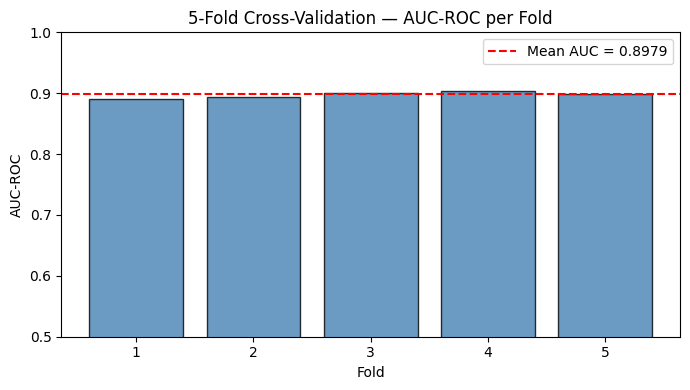

In [17]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print("Running 5-fold stratified CV on training set...")
cv_scores = cross_val_score(
    pipeline, X_train, y_train,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1
)

print(f"\nCV AUC-ROC per fold: {[round(s, 4) for s in cv_scores]}")
print(f"Mean AUC-ROC : {cv_scores.mean():.4f}")
print(f"Std  AUC-ROC : {cv_scores.std():.4f}")

plt.figure(figsize=(7, 4))
plt.bar(range(1, 6), cv_scores, color='steelblue', alpha=0.8, edgecolor='black')
plt.axhline(cv_scores.mean(), color='red', linestyle='--',
            label=f'Mean AUC = {cv_scores.mean():.4f}')
plt.ylim(0.5, 1.0)
plt.xlabel('Fold')
plt.ylabel('AUC-ROC')
plt.title('5-Fold Cross-Validation — AUC-ROC per Fold')
plt.legend()
plt.tight_layout()
plt.show()

### 11. Fit Final Model on Full Training Set

CV is used for model *selection and validation*; the pipeline is now refit on the entire training set to maximise the vocabulary and coefficient estimates before evaluating once on the held-out test set.

In [18]:
print("Fitting final pipeline on full training set...")
pipeline.fit(X_train, y_train)
print("Training complete.")

y_pred  = pipeline.predict(X_test)
y_probs = pipeline.predict_proba(X_test)[:, 1]
print("Predictions generated on test set.")

Fitting final pipeline on full training set...
Training complete.
Predictions generated on test set.


### 12. Evaluation — Classification Report & Confusion Matrix

In [19]:
print("=" * 60)
print(" CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Negative (0)', 'Positive (1)']))

print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision : {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall    : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score  : {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_probs):.4f}")

 CLASSIFICATION REPORT
              precision    recall  f1-score   support

Negative (0)       0.52      0.76      0.61      1620
Positive (1)       0.95      0.86      0.90      8380

    accuracy                           0.85     10000
   macro avg       0.73      0.81      0.76     10000
weighted avg       0.88      0.85      0.86     10000

Accuracy  : 0.8459
Precision : 0.9483
Recall    : 0.8631
F1 Score  : 0.9037
ROC-AUC   : 0.8931


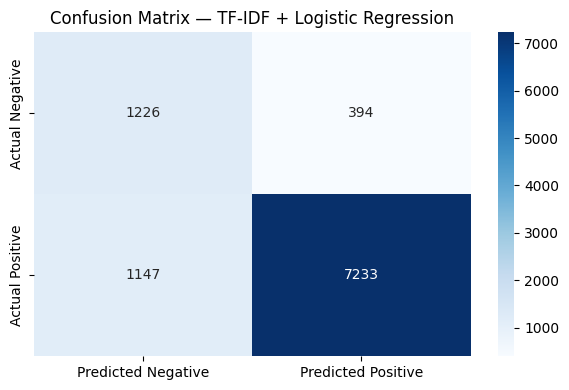

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])
plt.title('Confusion Matrix — TF-IDF + Logistic Regression')
plt.tight_layout()
plt.show()

### 13. ROC-AUC Curve

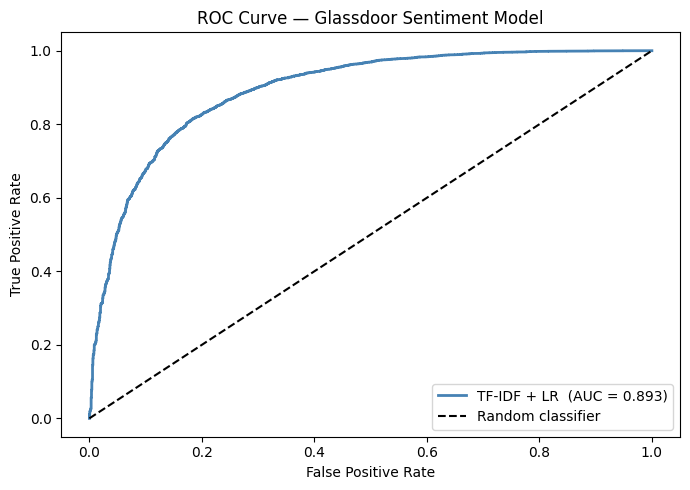

In [21]:
fpr, tpr, _ = roc_curve(y_test, y_probs)
auc_score   = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'TF-IDF + LR  (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Glassdoor Sentiment Model')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 14. Top TF-IDF Features — Positive vs Negative Sentiment

Logistic Regression coefficients directly indicate which words/phrases are most predictive of each class. High positive coefficients → strongly associated with positive reviews. High negative coefficients → strongly associated with negative reviews.

In [22]:
feature_names = pipeline.named_steps['tfidf'].get_feature_names_out()
coef          = pipeline.named_steps['clf'].coef_[0]

coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coef})
coef_df['abs_coef'] = coef_df['coefficient'].abs()

top_pos = coef_df.nlargest(20, 'coefficient').reset_index(drop=True)
top_neg = coef_df.nsmallest(20, 'coefficient').reset_index(drop=True)

print("TOP 20 POSITIVE SENTIMENT WORDS/PHRASES:")
print(top_pos[['feature', 'coefficient']].to_string(index=False))

print("\nTOP 20 NEGATIVE SENTIMENT WORDS/PHRASES:")
print(top_neg[['feature', 'coefficient']].to_string(index=False))

TOP 20 POSITIVE SENTIMENT WORDS/PHRASES:
      feature  coefficient
        great     6.826232
    sometimes     6.500646
         cons     4.926093
      amazing     4.283374
      no cons     4.200813
         best     3.873979
   supportive     3.862030
      awesome     3.620616
          bit     3.214128
    excellent     3.098986
 good culture     3.030037
great culture     3.019020
    very good     2.916052
      not too     2.722162
         love     2.697779
          fun     2.697154
      helpful     2.667206
       strong     2.628714
 good company     2.575788
collaborative     2.542254

TOP 20 NEGATIVE SENTIMENT WORDS/PHRASES:
    feature  coefficient
         no    -7.994572
       poor    -6.427074
      toxic    -6.387777
   terrible    -5.649105
   horrible    -5.529329
 management    -4.886446
      worst    -4.784919
        not    -4.741923
        bad    -4.079844
     morale    -4.005790
  some good    -3.968708
       name    -3.852676
 favoritism    -3.603605


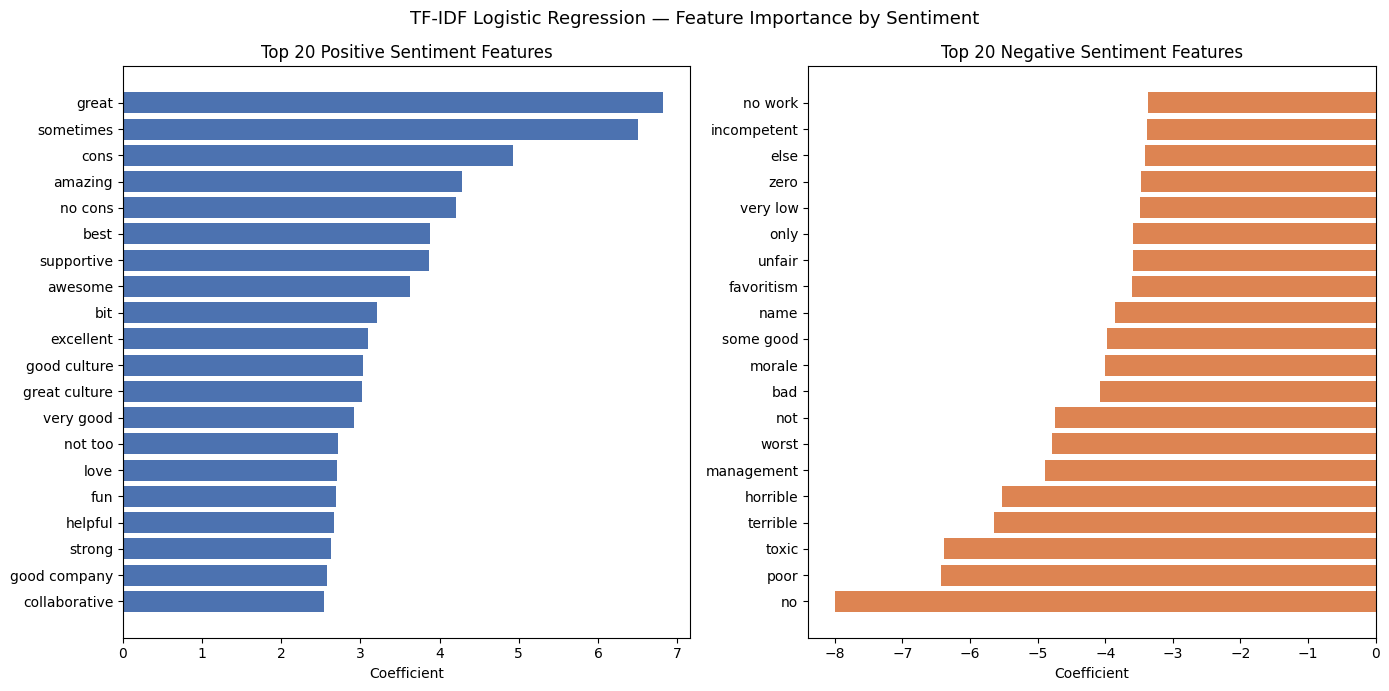

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Positive
axes[0].barh(top_pos['feature'][::-1], top_pos['coefficient'][::-1], color='#4C72B0')
axes[0].set_title('Top 20 Positive Sentiment Features')
axes[0].set_xlabel('Coefficient')

# Negative
axes[1].barh(top_neg['feature'], top_neg['coefficient'], color='#DD8452')
axes[1].set_title('Top 20 Negative Sentiment Features')
axes[1].set_xlabel('Coefficient')

plt.suptitle('TF-IDF Logistic Regression — Feature Importance by Sentiment', fontsize=13)
plt.tight_layout()
plt.show()

### 15. Per-Firm Sentiment Analysis (Test Set Only)

Predictions are made on the held-out test rows only to avoid any train-set leakage into the leaderboard. Firms with fewer than 50 test reviews are excluded as their estimates would be too noisy.

In [24]:
print("Predicting sentiment on test set...")


# Build a dataframe of just the test rows, keeping their firm info
test_df = gd_sample.loc[X_test.index].copy()
test_df['pred_positive_prob'] = pipeline.predict_proba(X_test)[:, 1]
test_df['pred_sentiment']     = (test_df['pred_positive_prob'] >= 0.5).astype(int)

firm_sentiment = (
    test_df.groupby('firm')
    .agg(
        n_reviews    = ('pred_sentiment', 'count'),
        pct_positive = ('pred_sentiment', lambda x: x.mean() * 100),
        avg_pos_prob = ('pred_positive_prob', 'mean'),
        avg_rating   = ('overall_rating', 'mean')
    )
    .sort_values('pct_positive', ascending=False)
    .reset_index()
)

MIN_REVIEWS_FOR_LEADERBOARD = 50

before = len(firm_sentiment)
firm_sentiment_filtered = firm_sentiment[
    firm_sentiment['n_reviews'] >= MIN_REVIEWS_FOR_LEADERBOARD
].reset_index(drop=True)

print(f"Removed {before - len(firm_sentiment_filtered)} firms with fewer than {MIN_REVIEWS_FOR_LEADERBOARD} test reviews")
print(f"Firms remaining: {len(firm_sentiment_filtered)}")
print(f"\n Excluded firms (too few test reviews):")
print(firm_sentiment[firm_sentiment['n_reviews'] < MIN_REVIEWS_FOR_LEADERBOARD][['firm', 'n_reviews']].to_string(index=False))

firm_sentiment = firm_sentiment_filtered
print(f"\n--- Final Leaderboard (n >= {MIN_REVIEWS_FOR_LEADERBOARD}) ---")
print(firm_sentiment.to_string(index=False))


Predicting sentiment on test set...
Removed 2 firms with fewer than 50 test reviews
Firms remaining: 23

 Excluded firms (too few test reviews):
         firm  n_reviews
Cisco-Systems         13
     Facebook         12

--- Final Leaderboard (n >= 50) ---
                firm  n_reviews  pct_positive  avg_pos_prob  avg_rating
              Google        430     88.604651      0.779977    4.537209
                 SAP        406     88.177340      0.776819    4.413793
McKinsey-and-Company        133     87.969925      0.788563    4.436090
            LinkedIn         86     83.720930      0.768966    4.569767
    American-Express        202     81.683168      0.735088    4.188119
            Vodafone        208     80.769231      0.698271    3.855769
               Apple        532     80.451128      0.714951    4.219925
          Salesforce        250     80.400000      0.738711    4.352000
           Microsoft        608     79.769737      0.713336    4.159539
            Deloitte   

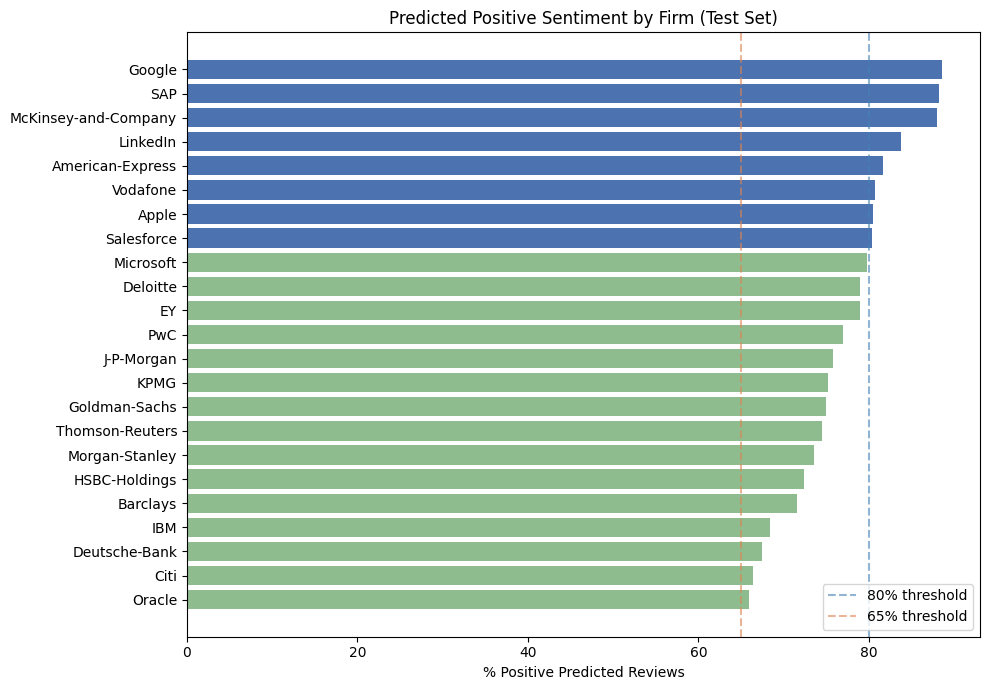

In [25]:
plt.figure(figsize=(10, 7))
colors = ['#4C72B0' if p >= 80 else '#DD8452' if p < 65 else '#8fbc8f'
          for p in firm_sentiment_filtered['pct_positive']]
plt.barh(
    firm_sentiment_filtered['firm'][::-1],
    firm_sentiment_filtered['pct_positive'][::-1],
    color=colors[::-1]
)
plt.axvline(80, color='steelblue', linestyle='--', alpha=0.6, label='80% threshold')
plt.axvline(65, color='#DD8452',   linestyle='--', alpha=0.6, label='65% threshold')
plt.xlabel('% Positive Predicted Reviews')
plt.title('Predicted Positive Sentiment by Firm (Test Set)')
plt.legend()
plt.tight_layout()
plt.show()

### 16. Save Model Artifacts

In [26]:
joblib.dump(pipeline,             "glassdoor_sentiment_pipeline.pkl")
joblib.dump(firm_sentiment,        "firm_sentiment_leaderboard.pkl")
import json

config = {
    "model_type": "TF-IDF + Logistic Regression",
    "scope": "Tech, Consulting, Finance sectors (Retail/Food Service/Hospitality excluded)",
    "allowed_firms": ALLOWED_FIRMS,
    "n_total_sample": int(len(gd_sample)),
    "n_train": int(len(X_train)),
    "n_test": int(len(X_test)),
    "tfidf_params": {
        "max_features": 5000,
        "ngram_range": [1, 2],
        "min_df": 3,
        "max_df": 0.90,
        "sublinear_tf": True
    },
    "test_auc_roc": float(roc_auc_score(y_test, y_probs)),
    "cv_auc_mean": float(cv_scores.mean()),
    "cv_auc_std": float(cv_scores.std()),
    "min_reviews_for_leaderboard": MIN_REVIEWS_FOR_LEADERBOARD,
}

with open("glassdoor_nlp_config.json", "w") as f:
    json.dump(config, f, indent=2)

print("Saved: glassdoor_nlp_config.json")
print(json.dumps(config, indent=2))

print("Saved: glassdoor_sentiment_pipeline.pkl  — full TF-IDF + LR pipeline")
print("Saved: firm_sentiment_leaderboard.pkl   — per-firm sentiment scores")

Saved: glassdoor_nlp_config.json
{
  "model_type": "TF-IDF + Logistic Regression",
  "scope": "Tech, Consulting, Finance sectors (Retail/Food Service/Hospitality excluded)",
  "allowed_firms": [
    "IBM",
    "Microsoft",
    "Oracle",
    "Apple",
    "Google",
    "SAP",
    "Salesforce",
    "LinkedIn",
    "Cisco-Systems",
    "Facebook",
    "Vodafone",
    "Deloitte",
    "EY",
    "PwC",
    "KPMG",
    "McKinsey-and-Company",
    "J-P-Morgan",
    "Citi",
    "HSBC-Holdings",
    "American-Express",
    "Barclays",
    "Goldman-Sachs",
    "Thomson-Reuters",
    "Morgan-Stanley",
    "Deutsche-Bank"
  ],
  "n_total_sample": 50000,
  "n_train": 40000,
  "n_test": 10000,
  "tfidf_params": {
    "max_features": 5000,
    "ngram_range": [
      1,
      2
    ],
    "min_df": 3,
    "max_df": 0.9,
    "sublinear_tf": true
  },
  "test_auc_roc": 0.8930640266360235,
  "cv_auc_mean": 0.8979108477874543,
  "cv_auc_std": 0.004698048377155966,
  "min_reviews_for_leaderboard": 50
}
Saved